In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import sklearn
import re
from sklearn.preprocessing import MinMaxScaler

In [3]:
world_cup = pd.read_csv("C:/Users/laila/Documents/Football Project/results.csv")

In [4]:
world_cup.columns = world_cup.columns.str.replace('_', '').str.upper()

In [5]:
print("Columns:", world_cup.columns.tolist())
print("Shape before filter:", world_cup.shape)

Columns: ['DATE', 'HOMETEAM', 'AWAYTEAM', 'HOMESCORE', 'AWAYSCORE', 'TOURNAMENT', 'CITY', 'COUNTRY', 'NEUTRAL']
Shape before filter: (48943, 9)


In [6]:
world_cup['DATE'] = pd.to_datetime(world_cup['DATE'], errors='coerce')

In [7]:
world_cup = world_cup[world_cup['DATE'] >= '1978-01-01']
world_cup = world_cup[world_cup['TOURNAMENT'] != 'Friendly']

In [8]:
print(f"\nRows after filter: {len(world_cup)}")
print(f"Date range: {world_cup['DATE'].min().date()} to {world_cup['DATE'].max().date()}")
print(f"Unique tournaments: {world_cup['TOURNAMENT'].nunique()}")


Rows after filter: 24835
Date range: 1978-03-05 to 2026-01-18
Unique tournaments: 158


In [9]:
print("\n--- First 5 rows ---")
print(world_cup.head())
 
print("\n--- Missing values ---")
print(world_cup.isnull().sum())
 
print("\n--- Descriptive stats ---")
print(world_cup.describe())


--- First 5 rows ---
            DATE      HOMETEAM      AWAYTEAM  HOMESCORE  AWAYSCORE  \
11282 1978-03-05         Ghana        Zambia          2          1   
11283 1978-03-05       Nigeria  Burkina Faso          4          2   
11284 1978-03-06         Congo        Uganda          1          3   
11285 1978-03-06       Morocco       Tunisia          1          1   
11286 1978-03-08  Burkina Faso        Zambia          0          2   

                   TOURNAMENT    CITY COUNTRY  NEUTRAL  
11282  African Cup of Nations   Accra   Ghana    False  
11283  African Cup of Nations   Accra   Ghana     True  
11284  African Cup of Nations  Kumasi   Ghana     True  
11285  African Cup of Nations  Kumasi   Ghana     True  
11286  African Cup of Nations   Accra   Ghana     True  

--- Missing values ---
DATE          0
HOMETEAM      0
AWAYTEAM      0
HOMESCORE     0
AWAYSCORE     0
TOURNAMENT    0
CITY          0
COUNTRY       0
NEUTRAL       0
dtype: int64

--- Descriptive stats ---
       

In [10]:
home = world_cup[['HOMETEAM', 'AWAYTEAM', 'HOMESCORE', 'AWAYSCORE']].copy()
home.columns = ['TEAM', 'OPPONENT', 'GOALS_SCORED', 'GOALS_CONCEDED']

In [11]:
away = world_cup[['AWAYTEAM', 'HOMETEAM', 'AWAYSCORE', 'HOMESCORE']].copy()
away.columns = ['TEAM', 'OPPONENT', 'GOALS_SCORED', 'GOALS_CONCEDED']
 

In [12]:
matches = pd.concat([home, away], ignore_index=True)

In [13]:
matches['WIN']         = (matches['GOALS_SCORED'] > matches['GOALS_CONCEDED']).astype(int)
matches['DRAW']        = (matches['GOALS_SCORED'] == matches['GOALS_CONCEDED']).astype(int)
matches['LOSS']        = (matches['GOALS_SCORED'] < matches['GOALS_CONCEDED']).astype(int)
matches['CLEAN_SHEET'] = (matches['GOALS_CONCEDED'] == 0).astype(int)

In [14]:
summary = matches.groupby('TEAM').agg(
    matches_played = ('TEAM',           'count'),
    goals_scored   = ('GOALS_SCORED',   'sum'),
    goals_conceded = ('GOALS_CONCEDED', 'sum'),
    clean_sheets   = ('CLEAN_SHEET',    'sum'),
    wins           = ('WIN',            'sum'),
    draws          = ('DRAW',           'sum'),
    losses         = ('LOSS',           'sum'),
).reset_index()

In [15]:
summary['goals_per_game']          = summary['goals_scored']   / summary['matches_played']
summary['goals_conceded_per_game'] = summary['goals_conceded'] / summary['matches_played']
summary['goal_diff_per_game']      = (summary['goals_scored'] - summary['goals_conceded']) / summary['matches_played']
summary['cleansheet_pct']          = summary['clean_sheets']   / summary['matches_played']
summary['win_rate']                = summary['wins']           / summary['matches_played']
 
print("\nSummary table shape:", summary.shape)
print(summary.head())


Summary table shape: (307, 13)
          TEAM  matches_played  goals_scored  goals_conceded  clean_sheets  \
0     Abkhazia              26            47              20            13   
1  Afghanistan              98           104             198            26   
2      Albania             242           210             374            63   
3     Alderney              66            34             320             2   
4      Algeria             327           537             309           134   

   wins  draws  losses  goals_per_game  goals_conceded_per_game  \
0    12     11       3        1.807692                 0.769231   
1    27     25      46        1.061224                 2.020408   
2    59     49     134        0.867769                 1.545455   
3     3      1      62        0.515152                 4.848485   
4   164     86      77        1.642202                 0.944954   

   goal_diff_per_game  cleansheet_pct  win_rate  
0            1.038462        0.500000  0.46153

In [16]:
wc_only = world_cup[world_cup['TOURNAMENT'] == 'FIFA World Cup'].copy()
wc_only['YEAR'] = wc_only['DATE'].dt.year

In [17]:
wc_home = wc_only[['YEAR', 'HOMETEAM']].rename(columns={'HOMETEAM': 'TEAM'})
wc_away = wc_only[['YEAR', 'AWAYTEAM']].rename(columns={'AWAYTEAM': 'TEAM'})
wc_teams = pd.concat([wc_home, wc_away], ignore_index=True)

In [18]:
wc_appearances = (
    wc_teams.drop_duplicates(subset=['TEAM', 'YEAR'])
            .groupby('TEAM')['YEAR']
            .nunique()
            .reset_index()
            .rename(columns={'YEAR': 'wc_appearances'})
)

In [19]:
print("\nTop 10 by WC appearances:")
print(wc_appearances.sort_values('wc_appearances', ascending=False).head(10))


Top 10 by WC appearances:
           TEAM  wc_appearances
2     Argentina              12
8        Brazil              12
63        Spain              12
25      Germany              12
23      England              10
62  South Korea              10
33        Italy              10
38       Mexico              10
24       France              10
5       Belgium               9


In [20]:
summary = summary.merge(wc_appearances, on='TEAM', how='left')
summary['wc_appearances'] = summary['wc_appearances'].fillna(0).astype(int)
 

In [21]:
summary = summary[
    (summary['matches_played'] >= 20) &
    (summary['wc_appearances'] >= 1)
].copy()
 
print(f"\nFIFA nations with 20+ competitive matches: {len(summary)}")


FIFA nations with 20+ competitive matches: 76


In [22]:
recent = world_cup[world_cup['DATE'] >= '2022-01-01'].copy()

In [23]:
home_r = recent[['HOMETEAM', 'AWAYTEAM', 'HOMESCORE', 'AWAYSCORE']].copy()
home_r.columns = ['TEAM', 'OPPONENT', 'GOALS_SCORED', 'GOALS_CONCEDED']

In [24]:
away_r = recent[['AWAYTEAM', 'HOMETEAM', 'AWAYSCORE', 'HOMESCORE']].copy()
away_r.columns = ['TEAM', 'OPPONENT', 'GOALS_SCORED', 'GOALS_CONCEDED']

In [25]:
matches_r = pd.concat([home_r, away_r], ignore_index=True)
matches_r['WIN'] = (matches_r['GOALS_SCORED'] > matches_r['GOALS_CONCEDED']).astype(int)

In [26]:
recent_form = matches_r.groupby('TEAM').agg(
    recent_matches = ('TEAM', 'count'),
    recent_wins    = ('WIN',  'sum'),
).reset_index()
recent_form['recent_win_rate'] = recent_form['recent_wins'] / recent_form['recent_matches']

In [27]:
summary = summary.merge(recent_form[['TEAM', 'recent_win_rate']], on='TEAM', how='left')
summary['recent_win_rate'] = summary['recent_win_rate'].fillna(0)

In [28]:
summary = summary[summary['TEAM'] != 'Russia'].copy()

In [29]:
metrics = [
    'goals_per_game',
    'goal_diff_per_game',
    'cleansheet_pct',
    'win_rate',
    'wc_appearances',
    'recent_win_rate',
    'wc2022_stage'
]

In [31]:
wc2022_stage = {
    'Argentina'    : 7,  # Winner
    'France'       : 6,  # Runner-up
    'Croatia'      : 5,  # 3rd place
    'Morocco'      : 4,  # 4th place (historic semi-final)
    'Netherlands'  : 3,  # Quarter-final
    'Brazil'       : 3,
    'England'      : 3,
    'Portugal'     : 3,
    'Japan'        : 2,  # Round of 16
    'South Korea'  : 2,
    'Australia'    : 2,
    'Senegal'      : 2,
    'Poland'       : 2,
    'Switzerland'  : 2,
    'United States': 2,
    'Spain'        : 2,
}
 
summary['wc2022_stage'] = summary['TEAM'].map(wc2022_stage).fillna(0)

In [32]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(summary[metrics])
scaled_df = pd.DataFrame(scaled, columns=[m + '_scaled' for m in metrics])

In [33]:
weights = {
    'goals_per_game_scaled'    : 0.10,  # attacking output
    'goal_diff_per_game_scaled': 0.20,  # overall dominance
    'cleansheet_pct_scaled'    : 0.15,  # defensive solidity
    'win_rate_scaled'          : 0.15,  # consistency
    'wc_appearances_scaled'    : 0.10,  # tournament pedigree
    'recent_win_rate_scaled'   : 0.15,  # current form
    'wc2022_stage_scaled'      : 0.15,  # most recent WC result
}

In [34]:
print("Weights sum:", sum(weights.values()))

Weights sum: 1.0


In [35]:
summary = summary.reset_index(drop=True)
summary['composite_score'] = sum(scaled_df[col] * w for col, w in weights.items())

In [36]:
summary = summary.sort_values('composite_score', ascending=False).reset_index(drop=True)
summary['rank'] = summary.index + 1
 
top20 = summary.head(20).copy()

In [37]:
print("\n=== TOP 20 WORLD CUP CONTENDERS ===")
print(top20[[
    'rank', 'TEAM', 'matches_played',
    'goals_per_game', 'goal_diff_per_game', 'cleansheet_pct',
    'win_rate', 'wc_appearances', 'recent_win_rate',
    'wc2022_stage', 'composite_score'
]].to_string(index=False))


=== TOP 20 WORLD CUP CONTENDERS ===
 rank          TEAM  matches_played  goals_per_game  goal_diff_per_game  cleansheet_pct  win_rate  wc_appearances  recent_win_rate  wc2022_stage  composite_score
    1         Spain             344        2.273256            1.523256        0.488372  0.665698              12         0.697674           2.0         0.831037
    2        France             333        1.879880            1.096096        0.471471  0.606607              10         0.604651           6.0         0.792056
    3       England             351        1.977208            1.341880        0.566952  0.586895              10         0.625000           3.0         0.790723
    4     Argentina             346        1.627168            0.760116        0.427746  0.546243              12         0.694444           7.0         0.769465
    5   Netherlands             331        2.190332            1.389728        0.483384  0.628399               8         0.581395           3.0         

In [38]:
summary.to_csv("C:/Users/laila/Documents/Football Project/summary_all_teams.csv", index=False)
top20.to_csv("C:/Users/laila/Documents/Football Project/top20_contenders.csv",    index=False)

In [39]:
print("\nFiles saved:")
print("  summary_all_teams.csv  — full ranked summary of all FIFA nations")
print("  top20_contenders.csv   — top 20 contenders for further analysis")


Files saved:
  summary_all_teams.csv  — full ranked summary of all FIFA nations
  top20_contenders.csv   — top 20 contenders for further analysis


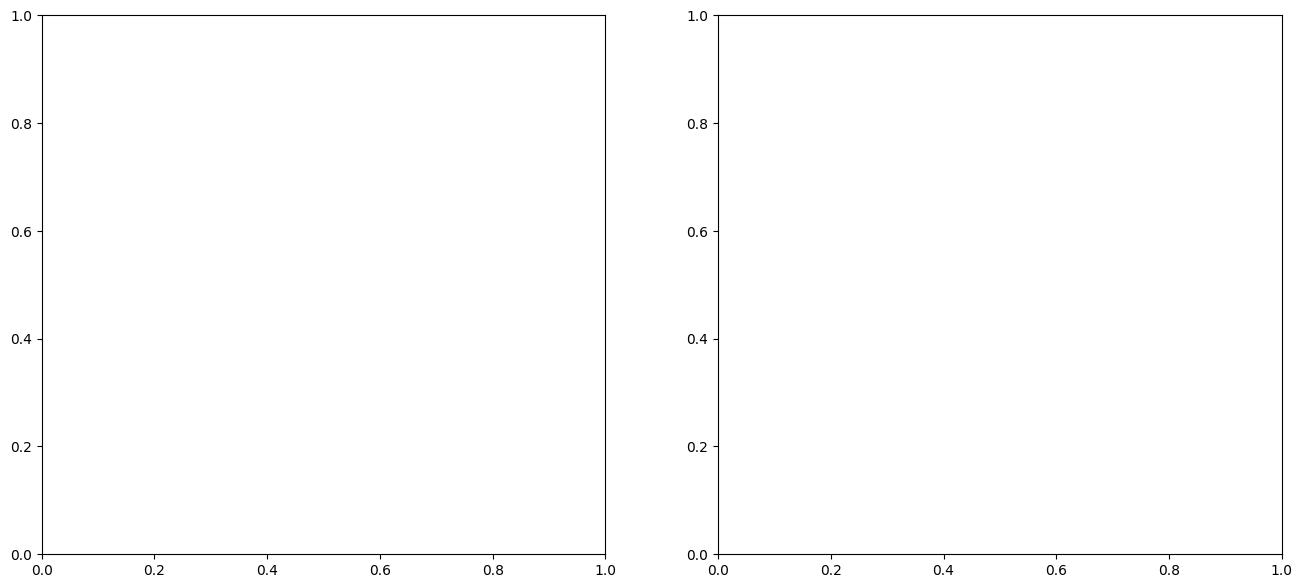

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

In [41]:
axes[0].barh(top20['TEAM'][::-1], top20['composite_score'][::-1], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Composite Score')
axes[0].set_title('Top 20 Contenders — Composite Score', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

In [42]:
axes[1].scatter(top20['goal_diff_per_game'], top20['cleansheet_pct'],
                color='coral', s=100, zorder=3, edgecolors='white', linewidths=0.5)
for _, row in top20.iterrows():
    axes[1].annotate(row['TEAM'],
                     (row['goal_diff_per_game'], row['cleansheet_pct']),
                     fontsize=7, ha='left', va='bottom', xytext=(3, 3),
                     textcoords='offset points')
axes[1].set_xlabel('Goal Difference per Game')
axes[1].set_ylabel('Clean Sheet %')
axes[1].set_title('Attack vs Defence — Top 20', fontweight='bold')
axes[1].grid(True, alpha=0.3)
 
plt.suptitle('2026 FIFA World Cup — Contender Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("C:/Users/laila/Documents/Football Project/top20_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

<Figure size 640x480 with 0 Axes>

Plot saved.


In [2]:
import pandas as pd

flags = {
    'Spain': '🇪🇸', 'England': '🏴󠁧󠁢󠁥󠁮󠁧󠁿', 'France': '🇫🇷',
    'Argentina': '🇦🇷', 'Brazil': '🇧🇷', 'Portugal': '🇵🇹',
    'Netherlands': '🇳🇱', 'Germany': '🇩🇪', 'Morocco': '🇲🇦',
    'Croatia': '🇭🇷', 'Japan': '🇯🇵', 'Belgium': '🇧🇪',
    'Iran': '🇮🇷', 'Australia': '🇦🇺', 'Senegal': '🇸🇳',
    'South Korea': '🇰🇷', 'Mexico': '🇲🇽', 'Ivory Coast': '🇨🇮',
    'United States': '🇺🇸', 'Switzerland': '🇨🇭', 'Algeria': '🇩🇿',
    'Egypt': '🇪🇬', 'Tunisia': '🇹🇳', 'Norway': '🇳🇴',
    'Uruguay': '🇺🇾', 'New Zealand': '🇳🇿', 'Uzbekistan': '🇺🇿',
    'Turkey': '🇹🇷', 'Ghana': '🇬🇭', 'Canada': '🇨🇦',
    'Sweden': '🇸🇪', 'Colombia': '🇨🇴', 'Austria': '🇦🇹',
    'Czech Republic': '🇨🇿', 'Jordan': '🇯🇴', 'Saudi Arabia': '🇸🇦',
    'Scotland': '🏴󠁧󠁢󠁳󠁣󠁴󠁿', 'Haiti': '🇭🇹', 'DR Congo': '🇨🇩',
    'South Africa': '🇿🇦', 'Qatar': '🇶🇦', 'Panama': '🇵🇦',
    'Cape Verde': '🇨🇻', 'Ecuador': '🇪🇨',
    'Bosnia and Herzegovina': '🇧🇦', 'Iraq': '🇮🇶',
    'Curacao': '🇨🇼', 'Paraguay': '🇵🇾',
}

# Check actual column names in each file first
files = [
    'wc2026_all48_summary',
    'monte_carlo_results_2026',
    'top20_contenders',
    'group_predictions',
    'stage_progression',
]

for filename in files:
    path = f"C:/Users/laila/Documents/Football Project/{filename}.csv"
    df = pd.read_csv(path)
    
    # Auto detect team column
    team_col = None
    for col in df.columns:
        if col.upper() == 'TEAM':
            team_col = col
            break
    
    if team_col is None:
        print(f"✗ {filename} — no TEAM column found. Columns: {df.columns.tolist()}")
        continue
    
    df['Flag'] = df[team_col].map(flags).fillna('')
    df['Team with Flag'] = df['Flag'] + ' ' + df[team_col]
    df.to_csv(path, index=False)
    print(f"✓ {filename} — used column '{team_col}'")

print("\nAll done!")

✓ wc2026_all48_summary — used column 'TEAM'
✓ monte_carlo_results_2026 — used column 'TEAM'
✓ top20_contenders — used column 'TEAM'
✓ group_predictions — used column 'Team'
✓ stage_progression — used column 'TEAM'

All done!
